# প্রকল্প ০১: কুমড়োর দাম পূর্বাভাস
## 🎃 লিনিয়ার রিগ্রেশন + পলিনোমিয়াল রিগ্রেশন

### 🎪 গল্প দিয়ে শুরু করি

**মনে করো,** তুমি একজন কুমড়ো চাষী। তুমি সারা বছর কুমড়ো产销 করো। কিন্তু তুমি জানো না — কখন কুমড়োর দাম বেশি থাকে? কখন দাম কমে?

যদি তুমি আগে থেকে জানতে পারো যে *ডিসেম্বর মাসে কুমড়োর দাম কমে যায়*, তাহলে তুমি অক্টোবর-নভেম্বরে বেশি দামে বিক্রি করতে পারবে!

**এখানেই মেশিন লার্নিং এর কাজ!** আমরা গত বছরের ডেটা দেখে শিখবো — কোন সময়ে কুমড়োর দাম কেমন থাকে। তারপর সেই শেখা ব্যবহার করে **ভবিষ্যতের দাম অনুমান** করবো!

---
## 📂 ডেটা লোড করা
প্রথমে আমরা Python এর লাইব্রেরি গুলো ইম্পোর্ট করবো এবং ডেটা লোড করবো।

In [1]:
# লাইব্রেরি ইম্পোর্ট করা হচ্ছে
import pandas as pd  # ডেটা ম্যানিপুলেশনের জন্য
import numpy as np  # গাণিতিক কাজের জন্য
import matplotlib.pyplot as plt  # গ্রাফ আঁকার জন্য
import seaborn as sns  # সুন্দর গ্রাফ আঁকার জন্য
from sklearn.model_selection import train_test_split  # ডেটা ভাগ করার জন্য
from sklearn.linear_model import LinearRegression  # লিনিয়ার রিগ্রেশন
from sklearn.preprocessing import PolynomialFeatures  # পলিনোমিয়াল ফিচার
from sklearn.pipeline import make_pipeline  # পাইপলাইন তৈরি
from sklearn.metrics import mean_squared_error, r2_score  # মূল্যায়ন

# ডেটা লোড করছি
df = pd.read_csv('pumpkins.csv')
print('ডেটার প্রথম ৫ সারি:')
display(df.head())
print(f'\nডেটার মোট সারি: {len(df)}, কলাম: {len(df.columns)}')


ডেটার প্রথম ৫ সারি:


,date,day_of_year,price,high_price,low_price,variety,month
0,2023-01-01,1,0.55,0.73,0.36,Pie,1
1,2023-01-02,2,0.50,0.71,0.25,Jack-o-Lantern,1
2,2023-01-03,3,0.58,0.78,0.40,Pie,1
3,2023-01-04,4,0.67,0.88,0.39,Pie,1
4,2023-01-05,5,0.50,0.66,0.35,Baby Boo,1



ডেটার মোট সারি: 365, কলাম: 7


## 🔍 ডেটা এক্সপ্লোরেশন (EDA)
ডেটার বিভিন্ন বৈশিষ্ট্য দেখি — কেমন ধরনের ডেটা আমাদের আছে?

In [2]:
# ডেটার সাধারণ তথ্য দেখি
print('=== ডেটার টাইপ ও নাল ভ্যালু ===')
print(df.info())
print('\n=== পরিসংখ্যান ===')
display(df.describe())

# বিভিন্ন জাতের কুমড়োর সংখ্যা
print('\n=== কুমড়োর জাত ===')
print(df['variety'].value_counts())

=== ডেটার টাইপ ও নাল ভ্যালু ===
<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         365 non-null    str    
 1   day_of_year  365 non-null    int64  
 2   price        365 non-null    float64
 3   high_price   365 non-null    float64
 4   low_price    365 non-null    float64
 5   variety      365 non-null    str    
 6   month        365 non-null    int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 20.1 KB
None

=== পরিসংখ্যান ===


,day_of_year,price,high_price,low_price,month
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,0.501151,0.699233,0.307096,6.526027
std,105.510663,0.228935,0.232022,0.236603,3.452584
min,1.000000,-0.120000,0.070000,-0.330000,1.000000
25%,92.000000,0.310000,0.520000,0.120000,4.000000
50%,183.000000,0.500000,0.700000,0.310000,7.000000
75%,274.000000,0.690000,0.890000,0.510000,10.000000
max,365.000000,1.020000,1.380000,0.860000,12.000000



=== কুমড়োর জাত ===
variety
Jack-o-Lantern    144
Pie               120
Cinderella         65
Baby Boo           36
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_2780\1797001771.py:16: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_2780\1797001771.py:16: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_2780\1797001771.py:16: UserWarning: Glyph 2459 (\N{BENGALI LETTER CHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_2780\1797001771.py:16: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_2780\1797001771.py:16: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_2780\1797001771.py:16: UserWarning: Glyph 2470 (\N{BENGALI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\User

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2470 (\N{BENGALI LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Use

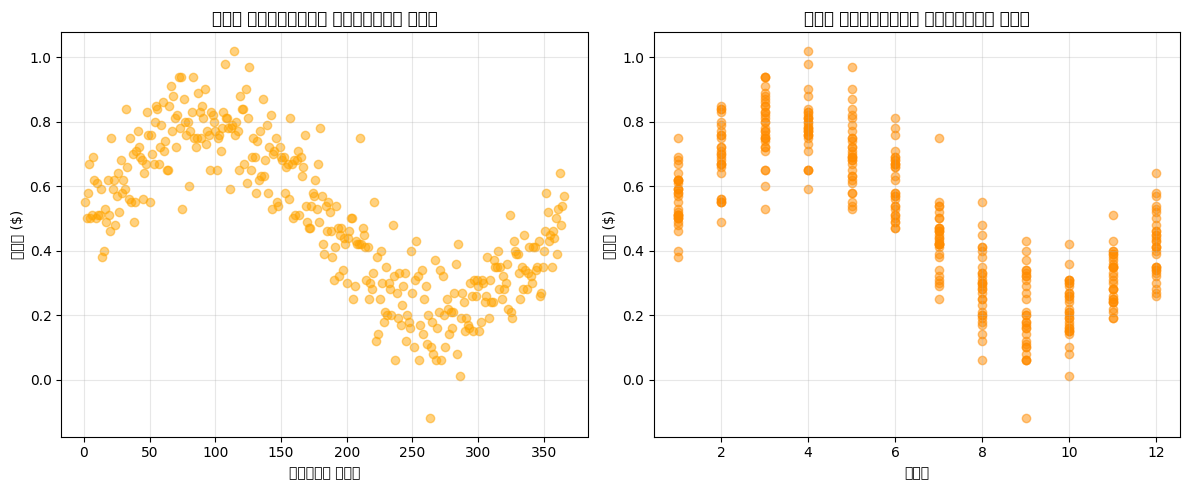

In [3]:
# সময়ের সাথে দামের পরিবর্তন দেখা যাক
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['day_of_year'], df['price'], alpha=0.5, color='orange')
plt.title('দিন অনুযায়ী কুমড়োর দাম')
plt.xlabel('বছরের দিন')
plt.ylabel('দাম ($)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(df['month'], df['price'], alpha=0.5, color='darkorange')
plt.title('মাস অনুযায়ী কুমড়োর দাম')
plt.xlabel('মাস')
plt.ylabel('দাম ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🤖 লিনিয়ার রিগ্রেশন
প্রথমে সরলরেখা (লিনিয়ার) দিয়ে দাম অনুমান করার চেষ্টা করি।

আমরা `day_of_year` (বছরের দিন) ব্যবহার করবো `price` (দাম) অনুমান করার জন্য।

In [4]:
# ফিচার (X) এবং টার্গেট (y) নির্ধারণ
X = df[['day_of_year']]  # ইনপুট: বছরের দিন
y = df['price']  # আউটপুট: দাম

# ডেটাকে ট্রেন (৮০%) এবং টেস্ট (২০%) এ ভাগ করি
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'ট্রেন ডেটা: {len(X_train)}টি, টেস্ট ডেটা: {len(X_test)}টি')

ট্রেন ডেটা: 292টি, টেস্ট ডেটা: 73টি


In [5]:
# লিনিয়ার রিগ্রেশন মডেল তৈরি
lin_model = LinearRegression()  # লিনিয়ার রিগ্রেশন অবজেক্ট
lin_model.fit(X_train, y_train)  # ট্রেন ডেটা দিয়ে শেখানো

# টেস্ট ডেটাতে পূর্বাভাস
y_pred_lin = lin_model.predict(X_test)

# ফলাফল মূল্যায়ন
mse_lin = mean_squared_error(y_test, y_pred_lin)  # মিন স্কোয়ার্ড এরর
r2_lin = r2_score(y_test, y_pred_lin)  # আর-স্কোয়ার্ড

print(f'🔵 লিনিয়ার রিগ্রেশন ফলাফল:')
print(f'   MSE (মিন স্কোয়ার্ড এরর): {mse_lin:.4f}')
print(f'   R² (আর-স্কোয়ার্ড): {r2_lin:.4f}')
print(f'   ঢাল (Slope): {lin_model.coef_[0]:.4f}')
print(f'   ছেদ (Intercept): {lin_model.intercept_:.4f}')

🔵 লিনিয়ার রিগ্রেশন ফলাফল:
   MSE (মিন স্কোয়ার্ড এরর): 0.0263
   R² (আর-স্কোয়ার্ড): 0.5108
   ঢাল (Slope): -0.0015
   ছেদ (Intercept): 0.7814


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2470 (\N{BENGALI LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Use

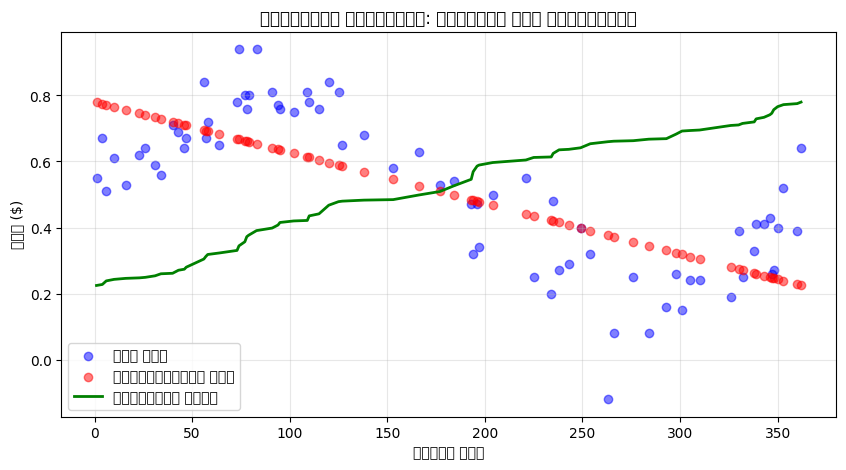

In [6]:
# লিনিয়ার রিগ্রেশন লাইন দেখা যাক
plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, alpha=0.5, label='আসল দাম', color='blue')
plt.scatter(X_test, y_pred_lin, alpha=0.5, label='পূর্বাভাসিত দাম', color='red')
plt.plot(sorted(X_test['day_of_year']), sorted(lin_model.predict(X_test)), 'g-', linewidth=2, label='রিগ্রেশন লাইন')
plt.title('লিনিয়ার রিগ্রেশন: কুমড়োর দাম পূর্বাভাস')
plt.xlabel('বছরের দিন')
plt.ylabel('দাম ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 🌀 পলিনোমিয়াল রিগ্রেশন
ডেটা হয়তো সরলরেখা নয়, বাঁকা হতে পারে। পলিনোমিয়াল রিগ্রেশন বাঁকা লাইন আঁকতে পারে!

In [7]:
# পলিনোমিয়াল রিগ্রেশন (ডিগ্রী ৩)
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(X_train, y_train)  # ট্রেন

# পূর্বাভাস
y_pred_poly = poly_model.predict(X_test)

# ফলাফল
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f'🟠 পলিনোমিয়াল রিগ্রেশন ফলাফল (ডিগ্রী ৩):')
print(f'   MSE: {mse_poly:.4f}')
print(f'   R²: {r2_poly:.4f}')

🟠 পলিনোমিয়াল রিগ্রেশন ফলাফল (ডিগ্রী ৩):
   MSE: 0.0090
   R²: 0.8322


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2470 (\N{BENGALI LETTER DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserW

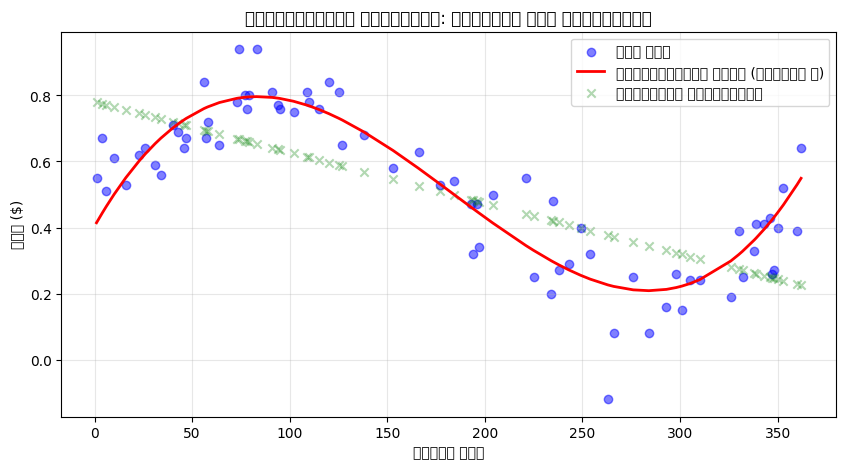

In [8]:
# পলিনোমিয়াল রিগ্রেশন ভিজুয়ালাইজেশন
X_sorted = np.sort(X_test['day_of_year']).reshape(-1, 1)
y_poly_sorted = poly_model.predict(X_sorted)

plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, alpha=0.5, label='আসল দাম', color='blue')
plt.plot(X_sorted, y_poly_sorted, 'r-', linewidth=2, label='পলিনোমিয়াল লাইন (ডিগ্রী ৩)')
plt.scatter(X_test, y_pred_lin, alpha=0.3, label='লিনিয়ার পূর্বাভাস', color='green', marker='x')
plt.title('পলিনোমিয়াল রিগ্রেশন: কুমড়োর দাম পূর্বাভাস')
plt.xlabel('বছরের দিন')
plt.ylabel('দাম ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# বিভিন্ন ডিগ্রী ট্রাই করা যাক
degrees = [2, 3, 4, 5]
results = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'ডিগ্রী': d, 'MSE': mse, 'R²': r2})
    print(f'ডিগ্রী {d}: MSE = {mse:.4f}, R² = {r2:.4f}')

ডিগ্রী 2: MSE = 0.0263, R² = 0.5104
ডিগ্রী 3: MSE = 0.0090, R² = 0.8322
ডিগ্রী 4: MSE = 0.0091, R² = 0.8301
ডিগ্রী 5: MSE = 0.0087, R² = 0.8378


## 📊 তুলনা ও সিদ্ধান্ত
দুইটি মডেলের ফলাফল পাশাপাশি তুলনা করি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

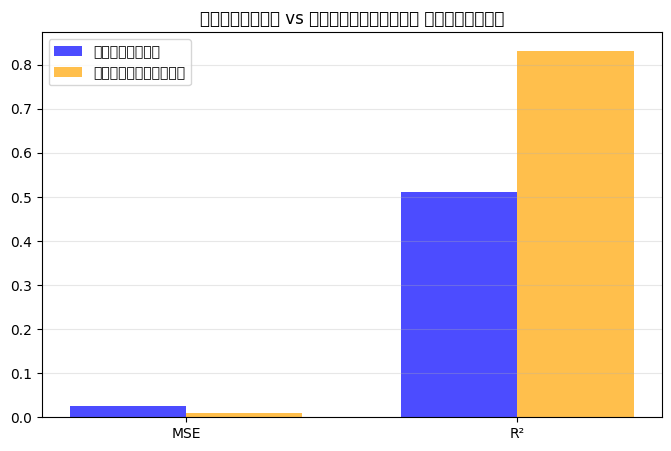


📊 উপসংহার:
লিনিয়ার রিগ্রেশন: MSE=0.0263, R²=0.5108
পলিনোমিয়াল রিগ্রেশন: MSE=0.0090, R²=0.8322

✅ R² যত বেশি, তত ভালো মডেল। MSE যত কম, তত ভালো মডেল।


In [10]:
# তুলনা গ্রাফ
metrics = ['MSE', 'R²']
lin_values = [mse_lin, r2_lin]
poly_values = [mse_poly, r2_poly]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, lin_values, width, label='লিনিয়ার', color='blue', alpha=0.7)
plt.bar(x + width/2, poly_values, width, label='পলিনোমিয়াল', color='orange', alpha=0.7)
plt.xticks(x, metrics)
plt.title('লিনিয়ার vs পলিনোমিয়াল রিগ্রেশন')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print(f'\n📊 উপসংহার:')
print(f'লিনিয়ার রিগ্রেশন: MSE={mse_lin:.4f}, R²={r2_lin:.4f}')
print(f'পলিনোমিয়াল রিগ্রেশন: MSE={mse_poly:.4f}, R²={r2_poly:.4f}')
print(f'\n✅ R² যত বেশি, তত ভালো মডেল। MSE যত কম, তত ভালো মডেল।')

## 🎯 তুমি কি শিখলে?

| ধারণা | বাংলায় অর্থ |
|-------|-------------|
| **লিনিয়ার রিগ্রেশন** | ডেটার মধ্যে সরলরেখা খুঁজে বের করে ভবিষ্যৎ বলা |
| **পলিনোমিয়াল রিগ্রেশন** | বাঁকা রেখা দিয়ে জটিল ডেটা বুঝতে পারে |
| **MSE** | মডেল কত ভুল করছে তা মাপার একক |
| **R² স্কোর** | মডেল কতটা ভালোভাবে ডেটা ব্যাখ্যা করতে পারছে |
| **ট্রেন/টেস্ট স্প্লিট** | ডেটার কিছু অংশ শেখার জন্য, কিছু অংশ পরীক্ষার জন্য আলাদা করা |

**মনে রাখবে:** সব ডেটা লিনিয়ার নয়! কখনো কখনো বাঁকা রেখার (পলিনোমিয়াল) প্রয়োজন হয়। কিন্তু খুব বেশি বাঁকালে ওভারফিটিং হতে পারে — মানে শুধু পুরনো ডেটা মনে রাখে, নতুন ডেটার জন্য ভালো কাজ করে না। 🎃